# Lab | Variational Autoencoder (VAE) on Fashion-MNIST Dataset

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model, datasets
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

Training data shape: (60000, 784)
Test data shape: (10000, 784)


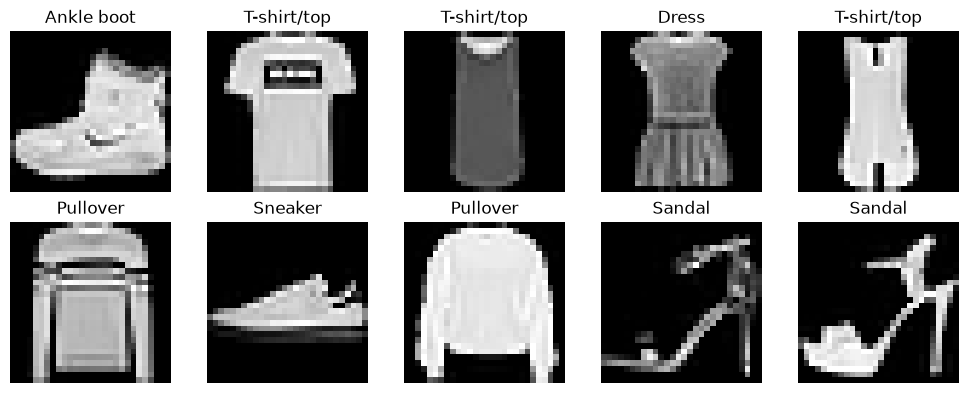

In [13]:
# Load and preprocess Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape to flatten the images
x_train = x_train.reshape(x_train.shape[0], 28 * 28)
x_test = x_test.reshape(x_test.shape[0], 28 * 28)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Fashion-MNIST class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Display some sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Sampling layer for the VAE
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z via the reparameterization trick."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        # epsilon is the random part, drawn from a fixed standard normal
        epsilon = K.random_normal(shape=(batch, dim))
        # z = mean + std * epsilon  -> deterministic + stochastic, fully differentiable
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [15]:
# Build the encoder
latent_dim = 2  # 2D latent space for easy visualization
original_dim = 28 * 28

encoder_inputs = layers.Input(shape=(original_dim,), name="encoder_input")
x = layers.Dense(256, activation="relu")(encoder_inputs)
x = layers.Dense(64, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        130 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling_2          │ (None, 2)         │          0 │ z_mean[0][0],     │
│ (Sampling)          │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 217,668 (850.27 KB)

 Trainable params: 217,668 (850.27 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Build the decoder
latent_inputs = layers.Input(shape=(latent_dim,), name="z_sampling")
x = layers.Dense(64, activation="relu")(latent_inputs)
x = layers.Dense(256, activation="relu")(x)
decoder_outputs = layers.Dense(original_dim, activation="sigmoid")(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,320 (852.81 KB)

 Trainable params: 218,320 (852.81 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Build the VAE model
class VAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # weight on the KL term (beta-VAE style)
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        # Sum of per-pixel binary cross-entropy, averaged over the batch.
        # Computed manually (not via tf.keras.losses.binary_crossentropy) because
        # that helper averages over the feature axis by default - we need the SUM
        # over the 784 pixels to match the VAE loss derivation.
        reconstruction_loss = -tf.reduce_mean(
            tf.reduce_sum(
                data * tf.math.log(reconstruction + 1e-7)
                + (1 - data) * tf.math.log(1 - reconstruction + 1e-7),
                axis=1,
            )
        )

        # KL divergence between the learned N(z_mean, exp(z_log_var)) and a standard normal.
        # Sum over latent dims first, THEN mean over the batch - both losses end up as
        # a single scalar on the same "per-sample" scale, so they combine correctly.
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, reconstruction_loss, kl_loss = self._compute_losses(data)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}


vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=0.001))

In [18]:
# Train the VAE
history = vae.fit(
    x_train, x_train,  # y is unused by train_step/test_step, only data[0] matters
    epochs=30,
    batch_size=128,
    validation_data=(x_test, x_test),
)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 7.1445 - loss: 301.6927 - reconstruction_loss: 294.5479 - val_kl_loss: 6.2648 - val_loss: 277.6895 - val_reconstruction_loss: 271.4249
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 6.1676 - loss: 272.9287 - reconstruction_loss: 266.7612 - val_kl_loss: 5.9690 - val_loss: 271.6016 - val_reconstruction_loss: 265.6327
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.1212 - loss: 269.0326 - reconstruction_loss: 262.9115 - val_kl_loss: 6.0058 - val_loss: 269.1343 - val_reconstruction_loss: 263.1285
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.1200 - loss: 266.8863 - reconstruction_loss: 260.7665 - val_kl_loss: 6.2402 - val_loss: 267.7206 - val_reconstruction_loss: 261.4803
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - kl_loss: 6.1123 - loss: 265.4164 - reconstruction_loss: 259.3043 - val_kl_loss: 6.1932 - val_loss: 266.4714 - val_reconstruction_loss: 260.2782
Epoch 6/30

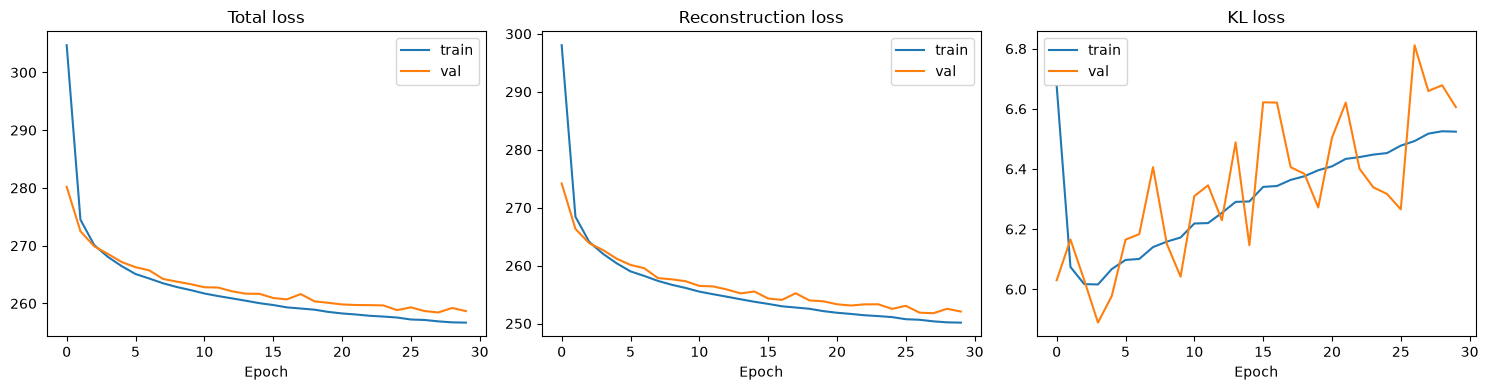

In [8]:
# Plot training history
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Total loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history["reconstruction_loss"], label="train")
plt.plot(history.history["val_reconstruction_loss"], label="val")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()


 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step


79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step


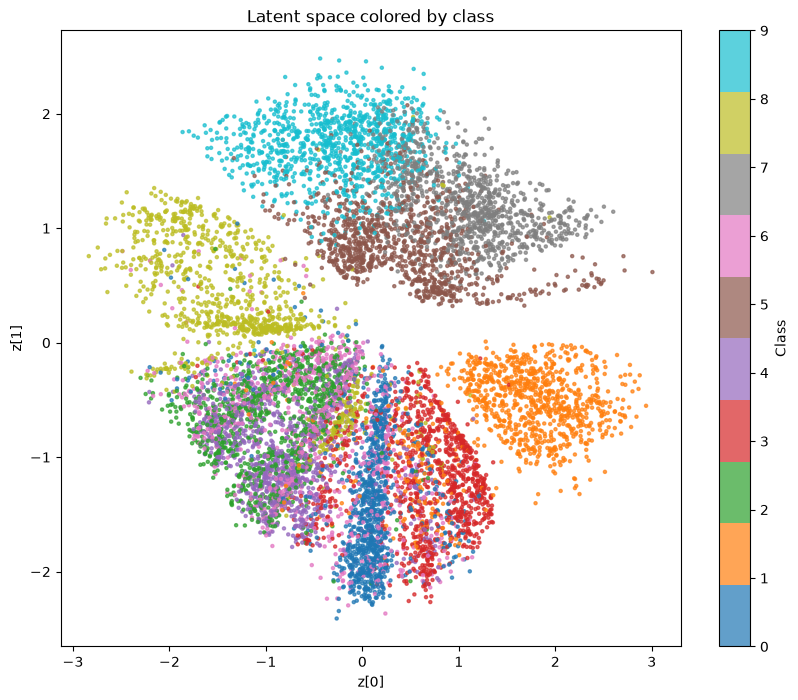

In [9]:
# Visualize the latent space
# Note: latent_dim is already 2 here, so we can scatter-plot it directly.
# TSNE (imported above) would only be needed if latent_dim were > 2.
z_mean, _, _ = encoder.predict(x_test, batch_size=128)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(z_mean[:, 0], z_mean[:, 1], c=y_test, cmap="tab10", s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="Class")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("Latent space colored by class")
plt.show()

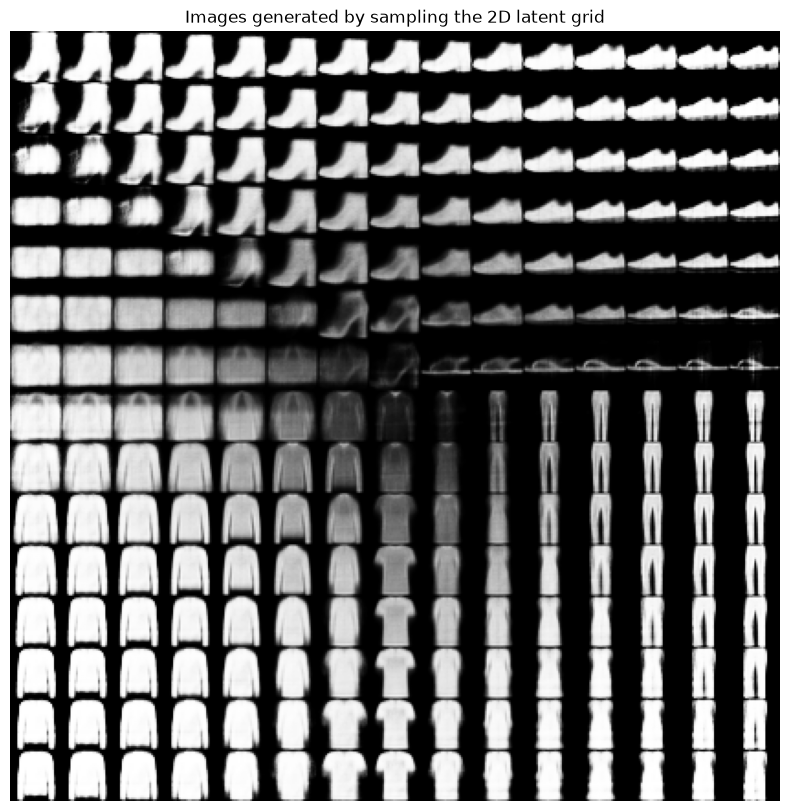

In [10]:
#####################################################
# Generate new images by sampling from latent space #
#####################################################

n = 15  # grid size (n x n images)
digit_size = 28
scale = 3.0
figure = np.zeros((digit_size * n, digit_size * n))

grid_x = np.linspace(-scale, scale, n)
grid_y = np.linspace(-scale, scale, n)[::-1]

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        x_decoded = decoder.predict(z_sample, verbose=0)
        digit = x_decoded[0].reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(10, 10))
plt.imshow(figure, cmap="gray")
plt.axis("off")
plt.title("Images generated by sampling the 2D latent grid")
plt.show()

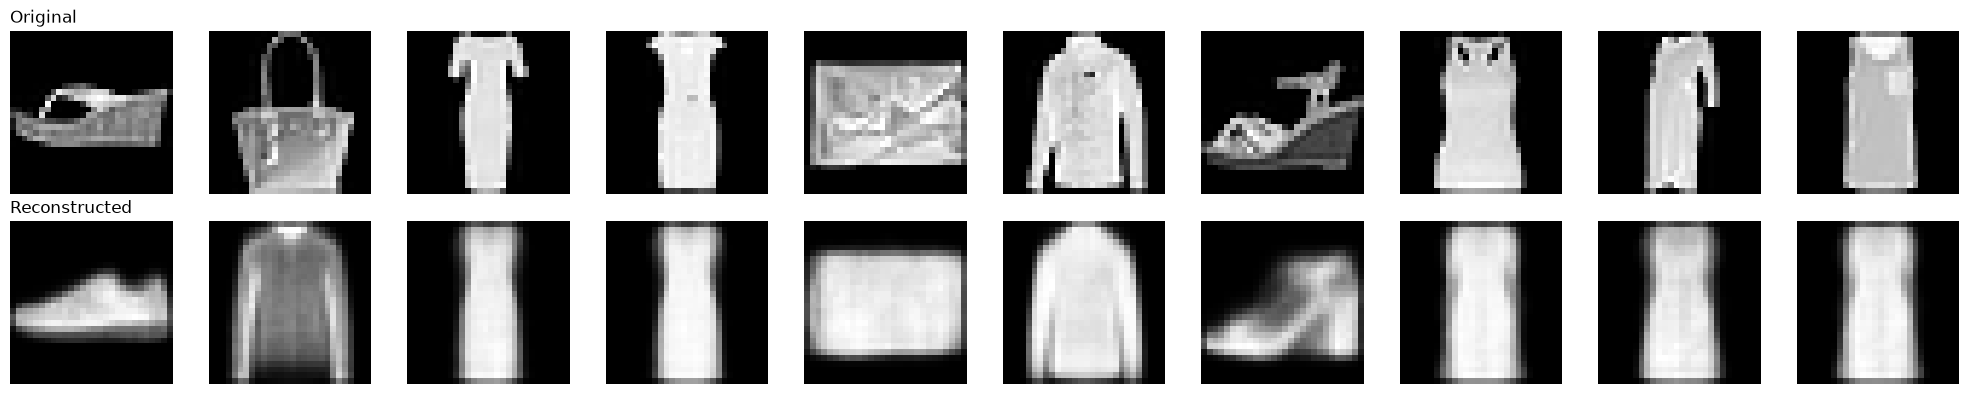

In [11]:
#############################################
# Compare original vs reconstructed images  #
#############################################

n_samples = 10
sample_idx = np.random.choice(len(x_test), n_samples, replace=False)
sample_images = x_test[sample_idx]

_, _, z = encoder.predict(sample_images, verbose=0)
reconstructions = decoder.predict(z, verbose=0)

plt.figure(figsize=(20, 4))
for i in range(n_samples):
    ax = plt.subplot(2, n_samples, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original", loc="left")

    ax = plt.subplot(2, n_samples, n_samples + i + 1)
    plt.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstructed", loc="left")

plt.tight_layout()
plt.show()